# Predicting MPRA fragment activity with `gena_expression`

This notebook evaluates whether model-derived expression or chromatin-track scores are associated with measured MPRA activity. Every fragment is reconstructed in the plasmid context used by the assay, centered on the reporter transcription start site (TSS), and evaluated under a HEK293T condition description.

## Workflow

1. Load the expression model, tokenizers, configuration, and checkpoint.
2. Aggregate replicate MPRA measurements by fragment and orientation.
3. Read fragment DNA from FASTA and reverse-complement reverse-orientation records.
4. Load the annotated plasmid, replace its cloning site with each fragment, and center the circular sequence on the TSS.
5. Build the HEK293T model condition from structured description metadata.
6. Select an expression or track-based scorer.
7. Predict all fragment contexts in batches with `predict_multiple_sequences(...)`.
8. Compare model scores with measured activity and explore individual points interactively.

The notebook demonstrates sequence annotations, plasmid editing, condition-aware inference, grouping-based batching, prediction retention policies, absolute single-prediction scoring, track visualization, and interactive Plotly output.

## 1. Runtime imports and API provenance

`gena_expression` provides the sequence, plasmid, model, condition, prediction, and scoring interfaces used throughout the analysis. Printing `gena_expression.__file__` records which installation is active, which is especially useful in notebook sessions where multiple package checkouts may be available. Matplotlib is used for sequence and track inspection; Plotly is used for the interactive result view; Polars manages the assay table.

In [1]:
import os
from collections.abc import Mapping
from pathlib import Path

import gena_expression
import matplotlib.pyplot as plt
import plotly.express as px
import polars as pl

from gena_expression import (
    AnnotatedSequence,
    DescriptionLookup,
    Feature,
    PlasmidRecord,
    SequenceModel,
)

from gena_expression.scoring.scorers import (
    ExpressionScorer,
    ScorerSet,
    TrackFeatureScorer,
    TrackWindowScorer,
    TrackAllFeaturesScorer
)

from gena_expression.dna.plasmid import centered_plasmid_window

## 2. Model, data, and batching configuration

The model class is addressed as `path/to/module.py::ClassName`, allowing `SequenceModel.load(...)` to construct a model directly from a Python file. The checkpoint and Hydra configuration define trained weights and architecture, while separate tokenizers encode DNA and condition descriptions.

`NUM_BEFORE`, `TOKEN_LEN_FOR_FETCH`, and the maximum sequence lengths control TSS-centered tokenization and must remain consistent with training. `DATA_DIR` is relative to the notebook working directory. Genome paths are available for genome-backed workflows, while the MPRA analysis uses the plasmid, fragment FASTA, activity table, and RNA-seq description directory.

The final three constants control batch execution: preprocessing workers prepare future rows, the forward limit bounds GPU memory use, and prefetching overlaps CPU preparation with model inference.

In [2]:
# Model repository and checkpoint configuration.
GENALM_HOME = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")
os.environ["GENALM_HOME"] = str(GENALM_HOME)

GENA_LM_ROOT = GENALM_HOME / "GENA_LM"
EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_FILE = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_FILE}::ExpressionCounts"
MODEL_CHECKPOINT = GENALM_HOME / "models" / "expression_model_v1-1" / "pytorch_model.bin"
MODEL_CONFIG = EXPRESSION_TASK_DIR / "configs" / "final.yaml"
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
)

DEVICE = "cuda:5"
RANDOM_SEED = 42
TOKEN_LEN_FOR_FETCH = 15
NUM_BEFORE = 512
DNA_MAX_SEQ_LEN = 1024
DESC_MAX_SEQ_LEN = 510

# Expression descriptions and MPRA assay inputs.
DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"
RNA_SEQ_DESCRIPTION_DIR = DATA_DIR / "rna_seq_generated_descriptions"
MPRA_DIR = DATA_DIR / "mpra_50"
MPRA_SEQUENCES = MPRA_DIR / "insertions.fa"
PLASMID_SEQUENCE = MPRA_DIR / "pLatinumSTARR_v1_winsert.fa"
PLASMID_ANNOTATION = MPRA_DIR / "platinum_starr_v1-winsert.gb"
ACTIVITIES = MPRA_DIR / "all_insertions_norm_log2ratio_RNA0.csv"

# Batch controls. Tune these to available CPU/GPU memory.
PREPROCESSING_WORKERS = 4
MAX_RECORDS_PER_FORWARD = 128
PREFETCH_BATCHES = 2

## 3. Validate resources and construct `SequenceModel`

The preflight check reports all missing local resources in one error before expensive model initialization begins. `SequenceModel.load(...)` then imports the configured model class, composes its configuration, restores checkpoint weights, loads both tokenizers, moves inference to the selected device, and returns the high-level prediction interface used by later cells.

In [3]:
required_inputs = [
    MODEL_FILE,
    MODEL_CHECKPOINT,
    MODEL_CONFIG,
    DNA_TOKENIZER,
    MPRA_SEQUENCES,
    PLASMID_SEQUENCE,
    PLASMID_ANNOTATION,
    ACTIVITIES,
    RNA_SEQ_DESCRIPTION_DIR,
]
missing = [path for path in required_inputs if not Path(path).exists()]
if missing:
    raise FileNotFoundError("Missing required input(s):\n" + "\n".join(map(str, missing)))

model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=DNA_MAX_SEQ_LEN,
    num_before=NUM_BEFORE,
    desc_max_seq_len=DESC_MAX_SEQ_LEN,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:172: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_im

Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

## 4. Build the measured-activity table

The assay table is restricted to `noSNP` fragments, because these rows represent the unmodified MPRA sequences being predicted. Replicate `log2ratio` measurements are averaged independently for each fragment identifier and orientation. Sorting creates deterministic row order, and the identifier and orientation columns are retained for sequence matching and Plotly hover labels.

In [4]:
activity_by_sequence = (
    pl.read_csv(ACTIVITIES)
    .filter(pl.col("variant_group") == "noSNP")
    .select(
        pl.col("chrom").alias("sequence_name"),
        "orientation",
        "log2ratio",
    )
    .group_by(["sequence_name", "orientation"])
    .agg(pl.col("log2ratio").mean().alias("observed_activity"))
    .sort(["sequence_name", "orientation"])
)

activity_by_sequence.head()

sequence_name,orientation,observed_activity
str,str,f64
"""1_11_chr11_65418158_65418613_b…","""forward""",1.132927
"""1_11_chr11_65418158_65418613_b…","""reverse""",0.751413
"""1_14_chr14_60655620_60656040_b…","""reverse""",-0.733701
"""1_15_chr15_40098659_40099167_b…","""forward""",1.991248
"""1_15_chr15_40098659_40099167_b…","""reverse""",1.481491


In [5]:
activity_by_sequence

sequence_name,orientation,observed_activity
str,str,f64
"""1_11_chr11_65418158_65418613_b…","""forward""",1.132927
"""1_11_chr11_65418158_65418613_b…","""reverse""",0.751413
"""1_14_chr14_60655620_60656040_b…","""reverse""",-0.733701
"""1_15_chr15_40098659_40099167_b…","""forward""",1.991248
"""1_15_chr15_40098659_40099167_b…","""reverse""",1.481491
…,…,…
"""2_5_chr12_2959230_2960351_fw""","""reverse""",-3.020527
"""2_6_chr12_57611320_57611561_fw""","""forward""",-2.361945
"""2_6_chr12_57611320_57611561_fw""","""reverse""",-0.05286


## 5. Parse fragment sequences from FASTA

The FASTA parser joins wrapped sequence lines, normalizes bases to uppercase, accepts `A/C/G/T/N`, and rejects empty records, invalid symbols, and duplicate identifiers. The text before the first colon in each header becomes the fragment key used to connect sequence data with assay measurements.

In [6]:
def read_fasta(path: str | Path) -> dict[str, str]:
    # Read a FASTA file into {name: uppercase_sequence}.
    records: dict[str, str] = {}
    current_name: str | None = None
    chunks: list[str] = []

    def store_record() -> None:
        if current_name is None:
            return
        sequence = "".join(chunks).upper()
        if not sequence:
            raise ValueError(f"FASTA record {current_name!r} has no sequence")
        invalid = sorted(set(sequence) - set("ACGTN"))
        if invalid:
            raise ValueError(f"FASTA record {current_name!r} contains: {''.join(invalid)}")
        #if current_name in records:
        #    raise ValueError(f"Duplicate FASTA identifier: {current_name!r}")
        if current_name in records:
            if len(sequence) < len(records[current_name]):
                return
        records[current_name] = sequence

    with Path(path).open(encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                store_record()
                current_name = line[1:].split(":", maxsplit=1)[0].strip()
                if not current_name:
                    raise ValueError("Encountered an empty FASTA identifier")
                chunks = []
            else:
                if current_name is None:
                    raise ValueError("FASTA sequence data appeared before the first header")
                chunks.append(line)
        store_record()

    return records


name_to_sequence = read_fasta(MPRA_SEQUENCES)
print(f"Loaded {len(name_to_sequence):,} insert sequences")

Loaded 55 insert sequences


## 6. Align measurements with DNA and apply assay orientation

A left join preserves every measured row while adding its FASTA sequence. Missing identifiers are checked explicitly so prediction rows cannot become misaligned with activity values. Forward records keep their FASTA sequence; reverse records are reverse-complemented before plasmid insertion. Unknown orientation labels raise immediately.

In [7]:
COMPLEMENT = str.maketrans("ACGTN", "TGCAN")


def orient_sequence(sequence: str, orientation: str) -> str:
    # Return the insert in the orientation used by the assay.
    if orientation == "forward":
        return sequence
    if orientation == "reverse":
        return sequence.translate(COMPLEMENT)[::-1]
    raise ValueError(f"Unsupported orientation: {orientation!r}")


sequence_lookup = pl.DataFrame(
    {
        "sequence_name": list(name_to_sequence),
        "raw_sequence": list(name_to_sequence.values()),
    }
)

mpra_records = activity_by_sequence.join(sequence_lookup, on="sequence_name", how="left")
missing_names = mpra_records.filter(pl.col("raw_sequence").is_null())["sequence_name"].unique().to_list()
if missing_names:
    preview = ", ".join(map(str, missing_names[:10]))
    raise KeyError(f"{len(missing_names)} activity names are absent from FASTA; first values: {preview}")

mpra_records = mpra_records.with_columns(
    pl.struct(["raw_sequence", "orientation"])
    .map_elements(
        lambda row: orient_sequence(row["raw_sequence"], row["orientation"]),
        return_dtype=pl.String,
    )
    .alias("oriented_sequence")
)

mpra_records.head()

sequence_name,orientation,observed_activity,raw_sequence,oriented_sequence
str,str,f64,str,str
"""1_11_chr11_65418158_65418613_b…","""forward""",1.132927,"""GGGCTGACACCGCAAAGTTCTTTCCTGTAA…","""GGGCTGACACCGCAAAGTTCTTTCCTGTAA…"
"""1_11_chr11_65418158_65418613_b…","""reverse""",0.751413,"""GGGCTGACACCGCAAAGTTCTTTCCTGTAA…","""GGAACTGGGGTGCACTCTCAGCCACACGTT…"
"""1_14_chr14_60655620_60656040_b…","""reverse""",-0.733701,"""AGGCCTGGTGGTCTCTGGGACTCTCCAGTT…","""GGGAGGCGAACTAGAGCTTTCGGCCGGGGA…"
"""1_15_chr15_40098659_40099167_b…","""forward""",1.991248,"""TCACACACGGACTGATTGTGTGCTCTGGTC…","""TCACACACGGACTGATTGTGTGCTCTGGTC…"
"""1_15_chr15_40098659_40099167_b…","""reverse""",1.481491,"""TCACACACGGACTGATTGTGTGCTCTGGTC…","""GCTCAGCGTCTAGATGGGACAGCCCCGGGC…"


## 7. Load the plasmid sequence and GenBank annotations

`PlasmidRecord.from_files(...)` combines bases from FASTA with feature coordinates parsed from GenBank. `reporter_feature_name="INSERT"` identifies the relevant reporter or cloning-site feature. Converting the record to `AnnotatedSequence` exposes these features to coordinate-aware editing, plotting, tokenization, and track scoring. The annotation plot verifies the plasmid structure before fragments are inserted.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'pLatinum_STARR_v1_w/ins'}, xlabel='Sequence coordinate'>)

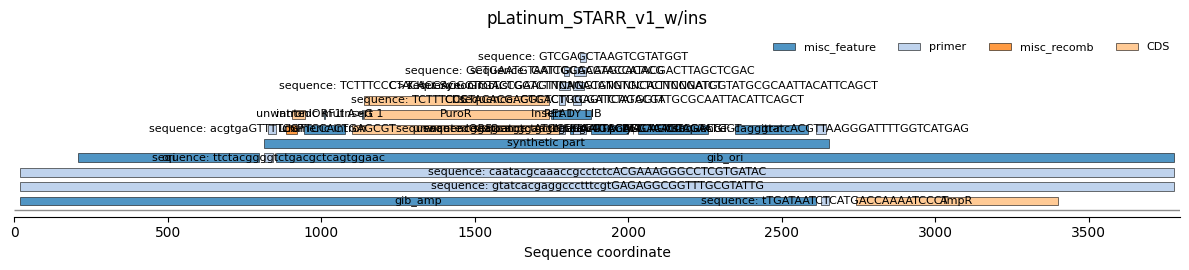

In [8]:
plasmid = PlasmidRecord.from_files(
    genbank_path=PLASMID_ANNOTATION,
    fasta_path=PLASMID_SEQUENCE,
    reporter_feature_name="INSERT",
)

plasmid.annotated_sequence().plot_annotations()

## 8. Reconstruct each assayed plasmid context

Each oriented fragment is wrapped in `AnnotatedSequence` and marked with an `insert` feature. The plasmid receives a one-base `tss` feature, the unique `INSERT` interval is replaced with the fragment, and `centered_plasmid_window(...)` rotates the circular molecule so the TSS is centered without losing feature coordinates.

The annotations serve two purposes: `center="tss"` gives the DNA tokenizer a reproducible model input center, and feature-aware scorers can later aggregate predicted tracks specifically over the inserted fragment.

In [9]:
TSS_POSITION = 315  # 0-based coordinate in the plasmid sequence


def embed_sequence(sequence: str, plasmid_record: PlasmidRecord) -> AnnotatedSequence:
    # Insert one MPRA fragment and return a TSS-centered circular plasmid context.
    insert = AnnotatedSequence(
        sequence,
        name="insert",
        features=[Feature(name="insert", type="insert", start=0, end=len(sequence))],
    )

    plasmid_sequence = plasmid_record.annotated_sequence().add_feature(
        name="tss",
        type="tss",
        start=TSS_POSITION,
        end=TSS_POSITION + 1,
    )

    cloning_sites = [feature for feature in plasmid_sequence.features if "INSERT" in feature.name]
    if len(cloning_sites) != 1:
        raise ValueError(
            f"Expected exactly one INSERT cloning-site feature, found {len(cloning_sites)}"
        )

    cloning_site = cloning_sites[0]
    edited_plasmid = plasmid_sequence.replace(
        start=cloning_site.start,
        end=cloning_site.end,
        replacement=insert,
    )

    return centered_plasmid_window(
        sequence=edited_plasmid,
        center=edited_plasmid.resolve_center("tss"),
        circular=True,
        size=len(edited_plasmid),
    )


plasmid_record = plasmid
mpra_records = mpra_records.with_columns(
    pl.col("oriented_sequence")
    .map_elements(
        lambda sequence: embed_sequence(sequence, plasmid_record),
        return_dtype=pl.Object,
    )
    .alias("sequence_in_context")
)

print(f"Constructed {mpra_records.height:,} annotated plasmid contexts")

Constructed 83 annotated plasmid contexts


## 9. Construct the HEK293T prediction condition

Expression prediction is conditioned on biological metadata as well as DNA. `DescriptionLookup` searches the JSON description collection for HEK293T and selects its structured record. `lookup.condition(...)` wraps that record as a `Condition`; the model's description formatter and tokenizer convert it into the language-model input paired with every plasmid sequence.

In [10]:
lookup = DescriptionLookup(json_dir=RNA_SEQ_DESCRIPTION_DIR, keys=["HEK293T"])
condition = lookup.condition("HEK293T")

print(condition)

Condition(name='HEK293T', description={'assay_term_name': 'RNA-seq', 'description': 'RNA-seq on human HEK293T, a transformed derivative of HEK293 from human fetal embryonic kidney cells, carrying SV40 large T antigen and widely used as an epithelial-like kidney/neuroectoderm-associated transfection and expression model; non-cancer transformed cell line.', 'biosample_summary': 'Homo sapiens HEK293T transformed embryonic kidney-derived cell line', 'life_stage_age': 'fetal', 'perturbed': False, 'strand_specificity': 'unstranded', 'genome_annotation': 'V29', 'mapped_run_type': 'paired-ended', 'id': 'ENC9Q7L2MA', 'genome': 'GRCh38'}, assay=None, cell_type='HEK293T', tissue=None, metadata={'json_dir': '/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/data/rna_seq_generated_descriptions'})


## 10. Select a scorer and inspect one full prediction

The scoring API separates model inference from downstream summaries. `ExpressionScorer` is the default; uncomment exactly one later assignment to override it with another analysis target:

- `ExpressionScorer` reads the absolute expression output; `transform="log2"` applies `log2(x + 1)`.
- `TrackWindowScorer` aggregates the predicted ATAC track over a fixed window centered on the TSS.
- `TrackFeatureScorer` aggregates the track only where it overlaps the annotated `insert` feature.
- `TrackAllFeaturesScorer` returns a score mapping for every annotation; `MAPPING_SCORE_KEY` chooses the entry used in the one-dimensional correlation and scatterplot.

Track-based scorers call `prediction.track(...)` and therefore need the sequence, logits, and token-coordinate metadata retained. The configuration cell detects these scorers and switches the batch from scalar-only retention to full retention automatically. Absolute track summaries can use `sum`, `mean`, `max`, `min`, `auc`, or `weighted_sum`; `max_abs_delta` is not offered because it requires a reference/alternative prediction pair.

A single full prediction is also visualized before the large batch: the first panel displays sequence annotations, and the second displays the coordinate-aware ATAC track.

Selected scorer: track_window


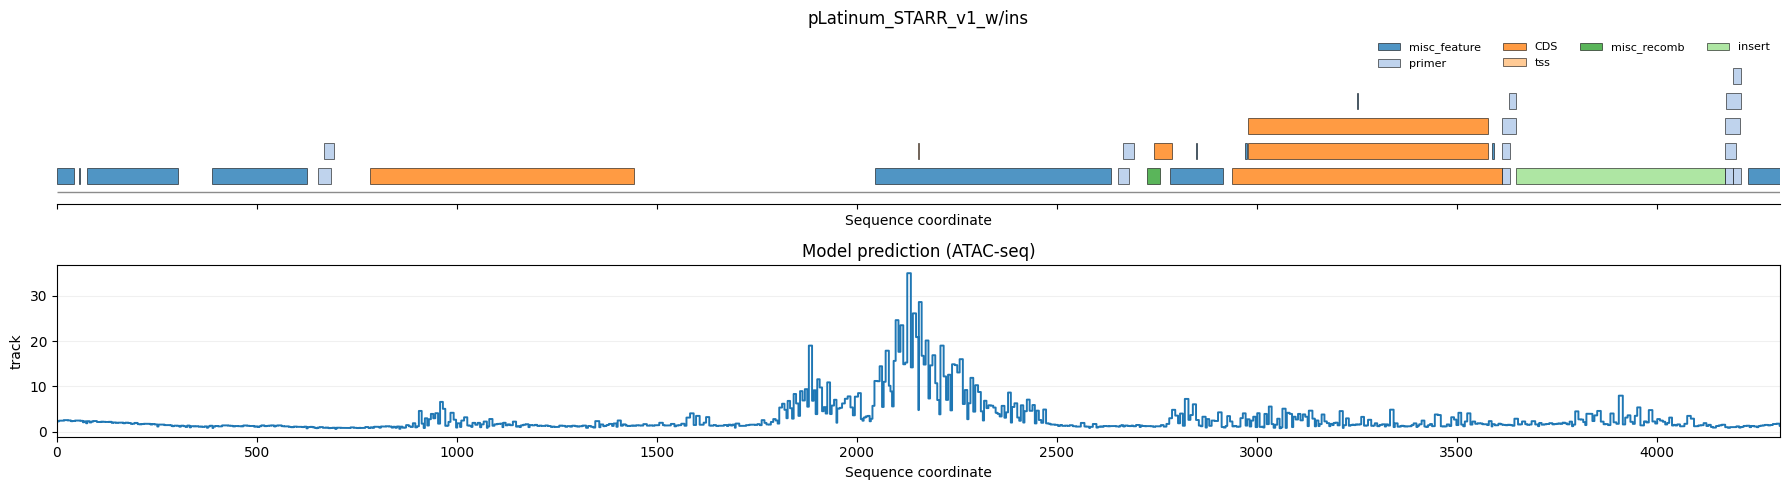

In [11]:
# ExpressionScorer is the default; uncomment one later assignment to override it.
# SCORER = ExpressionScorer()
# SCORER = ExpressionScorer(transform="log2", name="expression_log2")
SCORER = TrackWindowScorer(center="tss", width_bp=501, aggregate="sum")
# SCORER = TrackFeatureScorer(features="insert", aggregate="mean")
# SCORER = TrackAllFeaturesScorer(aggregate="mean")

# TrackAllFeaturesScorer returns a mapping; this key selects one value for correlation.
MAPPING_SCORE_KEY = "insert"

TRACK_SCORER_TYPES = (TrackWindowScorer, TrackFeatureScorer, TrackAllFeaturesScorer)
USES_TRACK_DATA = isinstance(SCORER, TRACK_SCORER_TYPES)
RETURN_TOKENS = USES_TRACK_DATA

print(f"Selected scorer: {SCORER.name}")

example_index = 1 if mpra_records.height > 1 else 0
example_sequence = mpra_records["sequence_in_context"][example_index]
example_prediction = model.predict_sequence(
    sequence=example_sequence,
    condition=condition,
    center="tss",
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 5), sharex=True)
example_sequence.plot_annotations(
    ax=axes[0],
    hide_types=("source", "transcript", "genome_interval"),
    label_features=False,
)
example_prediction.track().plot(
    ax=axes[1],
    color_by_sign=False,
    title="Model prediction (ATAC-seq)",
)
plt.tight_layout()

## 11. Run condition-grouped batch inference and score every fragment

`predict_multiple_sequences(...)` accepts many sequences with one broadcast condition. Because every row uses HEK293T, `grouping="condition"` reuses one condition encoding while processing different DNA inputs. This removes the repeated one-sequence-at-a-time model calls that would otherwise dominate the workflow.

Preprocessing workers prepare tokenized rows, prefetching keeps future batches ready, and `max_records_per_forward` limits each GPU forward pass. Predictions are reconstructed in input order, so their scores remain aligned with the sorted Polars table.

Each prediction is passed to `SCORER.score_prediction(...)`. Scalar scorers are converted directly to `model_score`; mapping scorers use `MAPPING_SCORE_KEY`. A prediction-count check and explicit mapping/list checks prevent silent row or output-shape mismatches.

In [12]:
sequences_in_context = mpra_records["sequence_in_context"].to_list()

predictions = model.predict_multiple_sequences(
    sequences=sequences_in_context,
    condition=condition,
    center="tss",
    grouping="condition",
    preprocessing_workers=PREPROCESSING_WORKERS,
    preprocessing_backend="process",
    max_records_per_forward=MAX_RECORDS_PER_FORWARD,
    prefetch_batches=PREFETCH_BATCHES,
    show_progress=True,
    return_tokens=RETURN_TOKENS,
)

if len(predictions) != mpra_records.height:
    raise RuntimeError(
        f"Expected {mpra_records.height} predictions, received {len(predictions)}"
    )

def scalar_score(prediction) -> float:
    scoring_result = SCORER.score_prediction(prediction)
    score = scoring_result.score

    if isinstance(score, Mapping):
        if MAPPING_SCORE_KEY not in score:
            available = ", ".join(map(str, score))
            raise KeyError(
                f"Score key {MAPPING_SCORE_KEY!r} is unavailable; choose from: {available}"
            )
        score = score[MAPPING_SCORE_KEY]

    if isinstance(score, list):
        raise TypeError("The selected scorer returned multiple values instead of one scalar")
    return float(score)


model_scores = [scalar_score(prediction) for prediction in predictions]

results = mpra_records.select(
    "sequence_name",
    "orientation",
    "observed_activity",
).with_columns(pl.Series("model_score", model_scores))

results.head()

sequence_name,orientation,observed_activity,model_score
str,str,f64,f64
"""1_11_chr11_65418158_65418613_b…","""forward""",1.132927,4598.171875
"""1_11_chr11_65418158_65418613_b…","""reverse""",0.751413,5184.148438
"""1_14_chr14_60655620_60656040_b…","""reverse""",-0.733701,2944.710938
"""1_15_chr15_40098659_40099167_b…","""forward""",1.991248,5499.992188
"""1_15_chr15_40098659_40099167_b…","""reverse""",1.481491,5883.609375


## 12. Quantify measured-versus-model association

Pearson correlation summarizes the linear association between mean MPRA `log2ratio` and the selected model score. The measured response and model output may use different units and scales, so correlation evaluates co-variation rather than agreement with an identity line. `results.describe()` provides complementary distribution and missing-value checks.

In [13]:
pearson_r = results.select(
    pl.corr("observed_activity", "model_score").alias("pearson_r")
)[0, "pearson_r"]

print(f"Scorer: {SCORER.name}")
print(f"Pearson r = {pearson_r:.4f}")

Scorer: track_window
Pearson r = 0.3657


## 13. Explore fragment-level results interactively

The Plotly scatterplot places measured MPRA activity on the x-axis and the selected model score on the y-axis. Hovering reveals the fragment identifier, orientation, and exact values, making outliers and orientation-specific behavior traceable back to individual sequences. Color distinguishes forward and reverse assay orientations, and the title records both the scorer and Pearson correlation.

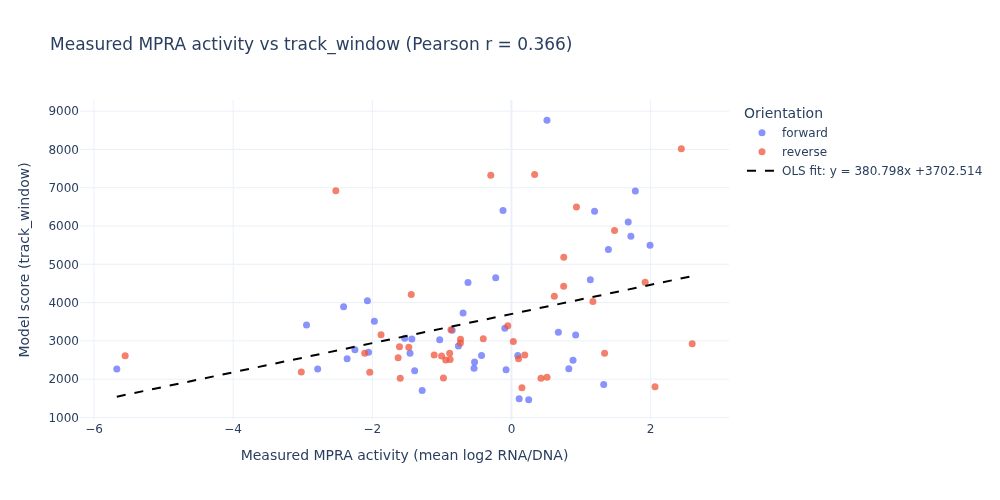

In [25]:
import math

#DELETE IF YOU RUN IN JUPYTER NOTEBOOK
import plotly.io as pio
pio.renderers.default = "png"
#####################################


# A dict-of-lists avoids requiring pandas only for plotting.
plot_data = results.to_dict(as_series=False)

fig = px.scatter(
    plot_data,
    x="observed_activity",
    y="model_score",
    color="orientation",
    hover_name="sequence_name",
    hover_data={
        "orientation": True,
        "observed_activity": ":.4f",
        "model_score": ":.4f",
    },
    labels={
        "observed_activity": "Measured MPRA activity (mean log2 RNA/DNA)",
        "model_score": f"Model score ({SCORER.name})",
        "orientation": "Orientation",
    },
    title=f"Measured MPRA activity vs {SCORER.name} (Pearson r = {pearson_r:.3f})",
    template="plotly_white",
    width=1000
)
fig.update_traces(marker={"size": 7, "opacity": 0.75})

# Fit model_score = slope * observed_activity + intercept over finite points.
regression_points = [
    (float(x), float(y))
    for x, y in zip(plot_data["observed_activity"], plot_data["model_score"])
    if x is not None
    and y is not None
    and math.isfinite(float(x))
    and math.isfinite(float(y))
]

if len(regression_points) >= 2:
    x_values, y_values = zip(*regression_points)
    mean_x = sum(x_values) / len(x_values)
    mean_y = sum(y_values) / len(y_values)
    x_variance = sum((x - mean_x) ** 2 for x in x_values)

    if x_variance > 0:
        slope = sum(
            (x - mean_x) * (y - mean_y)
            for x, y in regression_points
        ) / x_variance
        intercept = mean_y - slope * mean_x
        regression_x = [min(x_values), max(x_values)]
        regression_y = [slope * x + intercept for x in regression_x]

        fig.add_scatter(
            x=regression_x,
            y=regression_y,
            mode="lines",
            name=f"OLS fit: y = {slope:.3f}x {intercept:+.3f}",
            line={"color": "black", "width": 2, "dash": "dash"},
            hovertemplate="Regression line<br>model score=%{y:.4f}<extra></extra>",
        )

fig.update_layout(hovermode="closest")
fig.show()